In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    CAPTIONS_PATH,
    CVA_EM_PATH,
    DATA_DIR,
    ERA_EM_PATH,
    ERA_PATH,
    FIGURES_PATH,
    N_BURNIN,
    N_HANKEL_COLS,
    N_HANKEL_ROWS,
    N_LATENT_PATH,
    N_MARKOV,
    RANDOM_SEED,
)
from id import NOTEBOOK_GITHUB_URL, fit_cva_em, fit_era, fit_era_em, make_id_figure
from pgf_utils import (
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from system_estimate import SystemEstimate

In [2]:
# ── experiment constants ───────────────────────────────────────────────────────
NOISE_SEED  = 1        # brain seed for ERA noise covariance estimation
CVA_SEED    = 2        # brain seed for CVA+EM time series
DRIVE_SEED  = 42       # RNG seed for CVA+EM / ERA+EM random drive

N_NOISE_LAGS = 30
N_SAMPLES    = 5000    # timesteps for ERA noise estimation and CVA/ERA+EM training

HORIZON     = 30
MAX_EM_ITER = 200
EM_TOL      = 1e-6

# ERA+EM uses the same time-series data as CVA+EM for a fair comparison
ERA_EM_SEED       = CVA_SEED
ERA_EM_DRIVE_SEED = DRIVE_SEED

In [3]:
# ── derived: Brain dimensions and number of latent dimensions ──────────────────
_b = Brain(random_seed=RANDOM_SEED)
P_DIM = _b.input_dim
Q_DIM = len(_b.measure())
del _b

LATENT_DIM = int(np.load(N_LATENT_PATH)["n_latent"])  # shared by all methods

print(f"n_u = {P_DIM}")
print(f"n_y = {Q_DIM}")
print(f"n_x = {LATENT_DIM}  [from {N_LATENT_PATH}]")
print(f"N_SAMPLES = {N_SAMPLES}")

n_u = 2
n_y = 16
n_x = 6  [from /Users/tahmidazam/Developer/gg4/data/latent_dim.npz]
N_SAMPLES = 5000


In [4]:
# ── simulation: fit all estimators ────────────────────────────────────────────
est_era = fit_era(
    random_seed=RANDOM_SEED,
    noise_seed=NOISE_SEED,
    n_u=P_DIM,
    n_y=Q_DIM,
    n_latent=LATENT_DIM,
    n_markov=N_MARKOV,
    n_hankel_rows=N_HANKEL_ROWS,
    n_hankel_cols=N_HANKEL_COLS,
    n_noise_lags=N_NOISE_LAGS,
    n_samples=N_SAMPLES,
    n_burnin=N_BURNIN,
)

est_cva_em, logliks_cva = fit_cva_em(
    seed=CVA_SEED,
    drive_seed=DRIVE_SEED,
    n_latent=LATENT_DIM,
    n_samples=N_SAMPLES,
    n_burnin=N_BURNIN,
    horizon=HORIZON,
    max_em_iter=MAX_EM_ITER,
    em_tol=EM_TOL,
)

est_era_em, logliks_era_em = fit_era_em(
    era_seed=RANDOM_SEED,
    n_u=P_DIM,
    n_y=Q_DIM,
    n_latent=LATENT_DIM,
    n_markov=N_MARKOV,
    n_hankel_rows=N_HANKEL_ROWS,
    n_hankel_cols=N_HANKEL_COLS,
    em_seed=ERA_EM_SEED,
    em_drive_seed=ERA_EM_DRIVE_SEED,
    n_samples=N_SAMPLES,
    n_burnin=N_BURNIN,
    max_em_iter=MAX_EM_ITER,
    em_tol=EM_TOL,
)

ESTIMATES: list[SystemEstimate] = [est_era, est_cva_em, est_era_em]

for est in ESTIMATES:
    sr = float(np.max(np.abs(np.linalg.eigvals(est.A))))
    qmin = float(np.linalg.eigvalsh(est.Q).min())
    rmin = float(np.linalg.eigvalsh(est.R).min())
    print(
        f"{est.label:10s}  spectral radius = {sr:.4f}"
        f"  Q_min = {qmin:.2e}  R_min = {rmin:.2e}"
    )
print(f"CVA+EM EM converged in {len(logliks_cva)} iterations")
print(f"ERA+EM EM converged in {len(logliks_era_em)} iterations")

Impulse responses:   0%|          | 0/2 [00:00<?, ?it/s]

Noise statistics:   0%|          | 0/5000 [00:00<?, ?it/s]

EM refinement:   0%|          | 0/200 [00:00<?, ?iter/s]

Impulse responses:   0%|          | 0/2 [00:00<?, ?it/s]

EM refinement:   0%|          | 0/200 [00:00<?, ?iter/s]

ERA         spectral radius = 0.9661  Q_min = -6.71e-14  R_min = -5.11e-16
CVA+EM      spectral radius = 0.9408  Q_min = 4.46e-02  R_min = 5.09e-01
ERA+EM      spectral radius = 0.9666  Q_min = 9.49e-02  R_min = 5.19e-01
CVA+EM EM converged in 57 iterations
ERA+EM EM converged in 61 iterations


In [5]:
# ── save identified matrices ───────────────────────────────────────────────────
DATA_DIR.mkdir(parents=True, exist_ok=True)
for est, path in zip(ESTIMATES, [ERA_PATH, CVA_EM_PATH, ERA_EM_PATH]):
    est.save(path)
    print(f"{est.label:10s} saved to {path.resolve()}")

ERA        saved to /Users/tahmidazam/Developer/gg4/data/era_matrices.npz
CVA+EM     saved to /Users/tahmidazam/Developer/gg4/data/cva_em_matrices.npz
ERA+EM     saved to /Users/tahmidazam/Developer/gg4/data/era_em_matrices.npz


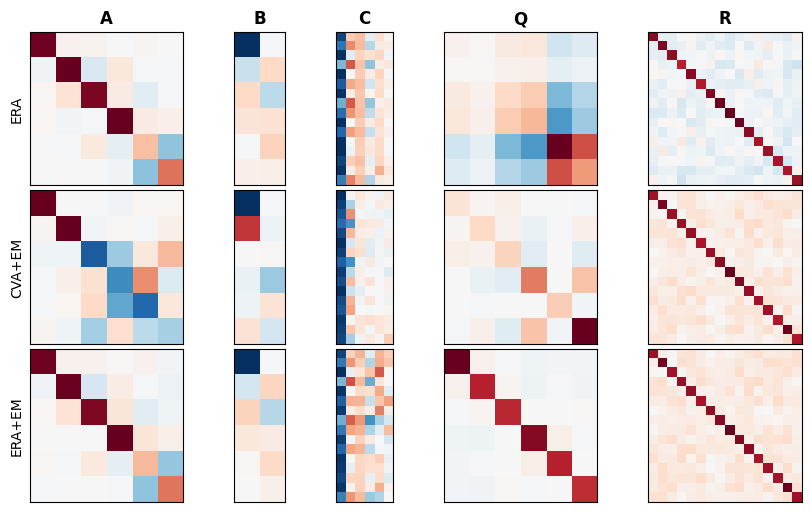

In [6]:
# ── display ────────────────────────────────────────────────────────────────────
configure_screen()
fig = make_id_figure(ESTIMATES, figsize=(8, 5))
plt.show()

In [7]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.5   # fraction of A4 content width
FIG_HEIGHT_FRAC = 0.20  # fraction of A4 content height (3 rows)

configure_pgf()
fig = make_id_figure(
    ESTIMATES,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "id.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/id.pgf


In [8]:

# ── caption ────────────────────────────────────────────────────────────────────
labels = ", ".join(
    (est.label if i < len(ESTIMATES) - 1 else f"and {est.label}")
    for i, est in enumerate(ESTIMATES)
)
caption = (
    rf"Identified system matrices for {labels} (rows, top to bottom). "
    r"Red indicates positive, blue negative; colour scales are symmetric about zero."
)
save_caption(CAPTIONS_PATH / "id.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)


Saved caption to /Users/tahmidazam/Developer/gg4/captions/id.tex
Identified system matrices for ERA, CVA+EM, and ERA+EM (rows, top to bottom). Red indicates positive, blue negative; colour scales are symmetric about zero.
